In [1]:
# 여기 코드 한줄한줄 아주 상세히 설명 좀 해줘. 왜 이런걸 썻고 왜 이런 문법을 썻고 이 함수가 뭐고 이 변수는 뭐고 그렇게

In [1]:
import torch
from transformers import AutoTokenizer, AutoModel
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

"""
HuggingFace 모델이랑 토크나이저 같은거 다 불러오자
참고로 tokenizer은.. 문자를 모델의 입력으로 바꿔주는 도구래! 
미리 학습되어있는거 불러오면 좋겠지?
"""
# model_name = "intfloat/e5-base"
model_name = "intfloat/multilingual-e5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name) # model_name 넣어주면 알아서 불러와줌
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

/home/0uk/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(250037, 384, padding_idx=0)
    (position_embeddings): Embedding(512, 384)
    (token_type_embeddings): Embedding(2, 384)
    (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
 

In [19]:
DATA_PATH = './data/book_meta.parquet'
df = pd.read_parquet(DATA_PATH)
df = df.dropna(subset=["title", "description"]) # 결측치 제거
df = df.reset_index(drop=True) # 기존 index 초기화, drop=true하면 기존 index를 컬럼으로 안만들고 걍 제거함

In [4]:
# 입력 텍스트 생성 (타이틀 + 설명 + 저자 등 결합)
def build_text(row):
    genres = ", ".join(row['genres'])
    parts = [
        f"Title: {row['title']}\n",
        f"Genres: {genres}\n",
        f"Description: {row['description']}"
    ]
    return " ".join( # 리스트의 문자열들을 공백으로 연결할건데.....
        [p for p in parts if isinstance(p, str)] # NaN이나 None이 있으면 제외함
    ) # 최종적으로 하나의 문장 형태로 반환한다고 함!! "Title: ... Author: ... Publisher: ... Description: ..."

df["text"] = df.apply(build_text, axis=1) # 새 컬럼 text에 대해서.... 문장 만듦

In [5]:
df['text'].head()

0    Title: تان تان والبحيرة الغامضة\n Genres: comi...
1    Title: Alice's Adventures in Wonderland\n Genr...
2    Title: Taught by America: A Story of Struggle ...
3    Title: Learning iPad Programming: A Hands-On G...
4    Title: A Rapariga Errada\n Genres: \n Descript...
Name: text, dtype: object

In [5]:
import pandas as pd
from collections import Counter

all_genres = [genre for sublist in df['genres'] for genre in sublist]

# 장르별 등장 횟수 계산
genre_counts = Counter(all_genres)

# DataFrame으로 보기 좋게 변환
genre_stats = pd.DataFrame(genre_counts.items(), columns=['genre','count']).sort_values(by='count', ascending=False)

print(genre_stats)

                                    genre    count
1                                 fiction  1106019
5  history, historical fiction, biography   571685
7                                 romance   541045
4                             non-fiction   485006
3                     fantasy, paranormal   448241
6                mystery, thriller, crime   386656
8                             young-adult   242891
2                                children   197293
0                         comics, graphic   132535
9                                  poetry    70215


In [28]:
# 멀티라벨인 책의 개수
multi_label_count = df['genres'].apply(len).gt(1).sum()
print(f"멀티라벨 책 개수: {multi_label_count}")

# 비율 확인
total_books = len(df)
multi_label_ratio = multi_label_count / total_books
print(f"전체 대비 비율: {multi_label_ratio:.2%}")

멀티라벨 책 개수: 771188
전체 대비 비율: 34.11%


In [ ]:
from datasets import Dataset
import numpy as np

# Hugging Face의 datasets는 메모리 대신 디스크 캐시 기반
data = {"book_id": df["book_id"], "text": df["text"]}
dataset = Dataset.from_dict(data)

"""
embed_batch 함수:
책 텍스트 리스트를 받아 E5 임베딩을 batch 단위로 만들어 반환함
얘는 대량으로 처리하기 좋은 방법이라서..... 뭐 정기적으로 대량임베딩하거나 할때 좋대
나중에 e5를 다른걸로 바꾸거나 뭐.... 모델 운영하다보면 semantic search가 부정확해지거나 할때 쓰면 굿
"""
def embed_batch(batch):
    batch_texts = [f"passage: {t}" for t in batch["text"]] # 각 텍스트 앞에 passage:를 붙힘!(e5 권장; 문맥 signal)

    inputs = tokenizer(
        batch_texts, return_tensors="pt", 
        truncation=True, # 길이 넘치면 자름
        padding=True,  # batch 단위로 다른 문장 길이에 맞게 padding
        max_length=256 # 최대 토큰 길이 제한
    ).to(device)

    with torch.no_grad():  # gradient 비활성화
        outputs = model(**inputs) # 딕셔너리를 언패킹(**)하여 모델에 전달
    
        emb = outputs.last_hidden_state.mean(dim=1)  # mean pooling
        # 원래는 아웃풋이 다 토큰단위인데.... mean해줘서 문장단위로 임베딩하게 된다는뎅
    
        emb = torch.nn.functional.normalize(emb, p=2, dim=1) # 정규화

    # pytorch 텐서는 기본적으로 연산 그래프를 추적해서 back-prop을 계산하나봐
    # 근데 .cpu().numpy()는 오직 gradient 추적 없는 순수 값(텐서)만 가능한 OP라서
    # .detach()를 통해서 그래프를 끊고 순수 값으로 탈바꿈 시킨대
    emb = emb.detach().cpu().numpy().tolist()
    return {"embedding": emb}

dataset = dataset.map(embed_batch, batched=True, batch_size=128)

In [9]:
book_emb_dict = { 
    int(row["book_id"]): np.array(row["embedding"], dtype=np.float32)
    for row in dataset # dict로 변환 (book_id -> np.array)
}
np.save("book_emb_dict.npy", book_emb_dict) # numpy로 저장
print("✅ book_emb_dict.npy 저장 완료!")

✅ book_emb_dict.npy 저장 완료!


In [4]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 예시: df['description'] 존재
df['description'] = df['description'].fillna('')

# TF-IDF 벡터화
tfidf = TfidfVectorizer(
    max_features=5000,  # 필요시 조정
    stop_words='english'  # 불용어 제거
)
tfidf_matrix = tfidf.fit_transform(df['description'])

print("TF-IDF 행렬 shape:", tfidf_matrix.shape)

TF-IDF 행렬 shape: (2260655, 5000)


In [5]:
book_idx = 0  # 첫 번째 책 예시
print(f"====== ex) book ====== \n{df.iloc[book_idx]} \n====================== ")

====== ex) book ====== 
book_id                                                  6474616
author_id                                                2802356
title                                   تان تان والبحيرة الغامضة
genres                      [comics, graphic, fiction, children]
description    A Tintin Film Book\nTintin, Snowy and Captain ...
Name: 0, dtype: object 


In [6]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 기준 책 index
book_idx = 150  # 첫 번째 책 예시
print(f"====== ex) book ====== \n{df.iloc[book_idx]} \n====================== ")

# 코사인 유사도 계산
sims = cosine_similarity(tfidf_matrix[book_idx], tfidf_matrix).flatten()

# 상위 K개 유사 책 인덱스
top_k = 10
top_idx = sims.argsort()[::-1][1:top_k+1]  # [1:] 자기 자신 제외

# 결과 확인
recommended_books = df.iloc[top_idx][['book_id','title','description']]
print(recommended_books)

====== ex) book ====== 
book_id                                                  1238611
author_id                                                 464760
title                                                 Marchlands
genres                                                 [fiction]
description    In "Marchlands", Karla Kuban's stunning first ...
Name: 150, dtype: object 
          book_id                                              title  \
2248611   9277537                             Sophie the Zillionaire   
1019428   9790958                                   Sophie the Snoop   
766374   26168073                          The Clairvoyant's Glasses   
1915481  26894851                          The Clairvoyant's Glasses   
1878357  26828238                          The Clairvoyant's Glasses   
1836518   4722983                                    Sophie Hits Six   
1659646  11071616                               Sophie the Daredevil   
1856946  24878317  Sophie la girafe: Pop-up Peeka

In [16]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import torch

# 예시 데이터 준비
# book_id, title, description
book_emb_dict = np.load("book_emb_dict.npy", allow_pickle=True).item()
book_emb_matrix = np.array(list(book_emb_dict.values()))

DATA_PATH = './data/user_book_sequence.parquet'
user_histories = pd.read_parquet(DATA_PATH)

# # 차원 축소 (PCA)
# pca = PCA(n_components=20)
# book_emb_reduced = pca.fit_transform(book_emb_matrix)
book_emb_reduced = book_emb_matrix

2-means 완료!..
3-means 완료!..
4-means 완료!..
5-means 완료!..
6-means 완료!..
7-means 완료!..
8-means 완료!..
9-means 완료!..
10-means 완료!..
11-means 완료!..
12-means 완료!..
13-means 완료!..
14-means 완료!..
15-means 완료!..
16-means 완료!..
17-means 완료!..
18-means 완료!..
19-means 완료!..
20-means 완료!..


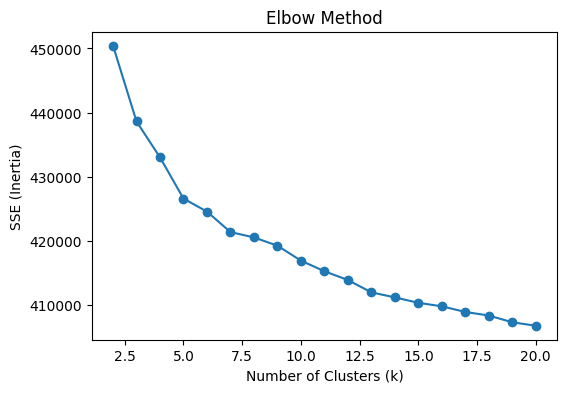

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ---------- 1. Elbow Method: inertia 계산 ----------
k_range = range(2, 21)
sse = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(book_emb_reduced)
    sse.append(kmeans.inertia_)
    print(f"{k}-means 완료!..")

# ---------- 2. Elbow Plot ----------
plt.figure(figsize=(6,4))
plt.plot(k_range, sse, 'o-')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE (Inertia)")
plt.show()

In [35]:
# 클러스터링
# 엘보우로 후보 k 3~4개 고르고
# 그 중 실루엣 점수가 가장 높은 k 선택 (실루엣 계산 빡셈)
# book_clusters
# cluster_to_books
books = df.copy()

num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(book_emb_reduced)

books['cluster'] = cluster_labels
book_clusters = {books.iloc[i]['book_id']: cluster_labels[i] for i in range(len(books))}

# cluster → book list
cluster_to_books = {}
for i in range(num_clusters):
    cluster_to_books[i] = books[books['cluster']==i]['book_id'].tolist()

print("Books with clusters:")
print(books[['book_id','title','cluster']])

Books with clusters:
          book_id                                              title  cluster
0         6474616                           تان تان والبحيرة الغامضة        4
1          445501                   Alice's Adventures in Wonderland        4
2          445503  Taught by America: A Story of Struggle and Hop...        5
3        11007713  Learning iPad Programming: A Hands-On Guide to...        9
4        12636575                                  A Rapariga Errada        6
...           ...                                                ...      ...
2260650   3084038  This Sceptred Isle, Vol. 10: The Age of Victor...        2
2260651  26168430                Sherlock Holmes and the July Crisis        5
2260652   2342551           The Children's Classic Poetry Collection        5
2260653  22017381          101 Nights: Volume One (101 Nights, #1-3)        0
2260654  11419866  The Spanish Duke's Virgin Bride (Innocent Mist...        3

[2260655 rows x 3 columns]


In [36]:
books.head()

,book_id,author_id,title,genres,description,cluster
0,6474616,2802356,تان تان والبحيرة الغامضة,"[comics, graphic, fiction, children]","A Tintin Film Book\nTintin, Snowy and Captain ...",4
1,445501,8164,Alice's Adventures in Wonderland,"[children, fantasy, paranormal, fiction]",Purchase one of 1st World Library's Classic Bo...,4
2,445503,250484,Taught by America: A Story of Struggle and Hop...,"[non-fiction, history, historical fiction, bio...","After graduating from Yale University, Sarah S...",5
3,11007713,4767184,Learning iPad Programming: A Hands-On Guide to...,[non-fiction],"""Learning iPad Programming"" walks you through ...",9
4,12636575,1385066,A Rapariga Errada,[],O novo livro de Pedro Paixao trata de uma curi...,6


In [37]:
for c in sorted(books['cluster'].unique()):
    print(f"\n=== Cluster {c} ===")
    print(books[books['cluster'] == c]['title'].head(10))


=== Cluster 0 ===
27     Vengeance Fulfilled (The Raven Falconer Chroni...
39                                         Never a Bride
46                           And God Created the Au Pair
59                                        North of Happy
61                                  Undermajordomo Minor
73                                She Wolf Montana Bride
95                                         The Jennifers
106                                           Lady Maybe
108                          Claimed (Hunter's Moon, #1)
113                                          Black Heart
Name: title, dtype: object

=== Cluster 1 ===
6                                                 Kenya
9     The Islamic State of Iraq and Syria: The Histo...
11           American Legends: The Life of Gene Tierney
12                                          Night Watch
18                                          The Red Wig
24                    The Ghost of the Bermuda Triangle
31                           

In [38]:
books.explode('genres').groupby('cluster')['genres'].value_counts().groupby(level=0).head(10)

cluster  genres                                
0        romance                                   207436
         fiction                                   202442
         fantasy, paranormal                       124126
         young-adult                                71583
         history, historical fiction, biography     52514
                                                    ...  
9        comics, graphic                             5064
         fantasy, paranormal                         3619
         poetry                                      2944
         romance                                     2525
         mystery, thriller, crime                    1626
Name: count, Length: 100, dtype: int64

In [39]:
# cluster_evaluation.py
import numpy as np
import pandas as pd
import random
from collections import Counter

from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score
)
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt

def sample_indices(n, sample_size, random_state=42):
    rng = np.random.RandomState(random_state)
    if sample_size >= n:
        return np.arange(n)
    return rng.choice(n, size=sample_size, replace=False)

def evaluate_clusters(
    embeddings,          # numpy array (n_samples, dim)
    labels,              # array-like (n_samples,)
    genres=None,         # optional list/array of ground-truth genre labels (n_samples,)
    sample_size=50000,
    random_state=42,
    umap_n_neighbors=15,
    umap_min_dist=0.1,
    verbose=True
):
    """
    Returns dict of metrics and also creates diagnostic plots (silhouette hist, UMAP scatter).
    For very large datasets, sample_size controls silhouette sampling.
    """
    embeddings = np.asarray(embeddings)
    labels = np.asarray(labels)
    n, d = embeddings.shape
    unique_labels = np.unique(labels)
    k = len(unique_labels)

    out = {}
    if verbose:
        print(f"n={n}, dim={d}, clusters={k}, sample_size={sample_size}")

    # 1) Cluster size distribution
    counts = Counter(labels)
    cluster_sizes = {int(l): int(c) for l,c in counts.items()}
    out['cluster_sizes'] = cluster_sizes
    if verbose:
        print("cluster sizes (top 10):", sorted(cluster_sizes.items(), key=lambda x:-x[1])[:10])

    # 2) Global metrics (CH, DB) - compute on entire data if feasible
    try:
        ch = calinski_harabasz_score(embeddings, labels)
        db = davies_bouldin_score(embeddings, labels)
        out['calinski_harabasz'] = ch
        out['davies_bouldin'] = db
        if verbose:
            print(f"Calinski-Harabasz: {ch:.3f}, Davies-Bouldin: {db:.3f}")
    except Exception as e:
        out['calinski_harabasz'] = None
        out['davies_bouldin'] = None
        if verbose:
            print("CH/DB computation failed:", e)

    # 3) Silhouette (sampled)
    idx = sample_indices(n, sample_size, random_state)
    emb_s = embeddings[idx]
    lab_s = labels[idx]
    try:
        sil_global = silhouette_score(emb_s, lab_s, metric='cosine', sample_size=None)
        sil_samples = silhouette_samples(emb_s, lab_s, metric='cosine')
        out['silhouette_global_sampled'] = float(sil_global)
        out['silhouette_samples'] = sil_samples  # can be large
        if verbose:
            print(f"Silhouette (sampled {len(idx)}): {sil_global:.4f}")
    except Exception as e:
        out['silhouette_global_sampled'] = None
        out['silhouette_samples'] = None
        if verbose:
            print("Silhouette computation failed:", e)

    # 4) Per-cluster silhouette summary (from sampled)
    if out.get('silhouette_samples') is not None:
        df_s = pd.DataFrame({'label': lab_s, 'sil': sil_samples})
        per_cluster_sil = df_s.groupby('label')['sil'].agg(['mean','median','std','count']).to_dict()
        out['per_cluster_silhouette'] = per_cluster_sil
        if verbose:
            # print top/bottom clusters by mean silhouette
            means = {k: v[0] for k,v in out['per_cluster_silhouette'].items()}
            sorted_means = sorted(means.items(), key=lambda x:-x[1])
            print("Top 5 clusters by silhouette mean:", sorted_means[:5])
            print("Bottom 5 clusters by silhouette mean:", sorted_means[-5:])
    else:
        out['per_cluster_silhouette'] = None

    # 5) Centroids and centroid distances
    centroids = []
    label_to_idx = {}
    for lab in unique_labels:
        mask = (labels == lab)
        label_to_idx[int(lab)] = np.where(mask)[0]
        centroid = embeddings[mask].mean(axis=0)
        centroids.append(centroid)
    centroids = np.vstack(centroids)
    # centroid pairwise cosine distances approximate separation
    from sklearn.metrics.pairwise import cosine_distances
    centroid_dists = cosine_distances(centroids)
    out['centroid_distance_mean'] = float(centroid_dists.mean())
    out['centroid_distance_min'] = float(centroid_dists[centroid_dists>0].min())
    if verbose:
        print(f"Centroid mean distance: {out['centroid_distance_mean']:.4f}, min (nonzero): {out['centroid_distance_min']:.4f}")

    # 6) Purity if genres provided
    if genres is not None:
        genres = np.asarray(genres)
        if genres.shape[0] != n:
            raise ValueError("genres length mismatch")
        # compute purity: for each cluster, majority genre count / cluster size
        purity_sum = 0
        cluster_purities = {}
        for lab in unique_labels:
            idxs = np.where(labels==lab)[0]
            if len(idxs)==0:
                cluster_purities[int(lab)] = {'purity': None, 'size':0}
                continue
            top_genre, top_count = Counter(genres[idxs]).most_common(1)[0]
            pur = top_count / len(idxs)
            cluster_purities[int(lab)] = {'purity': float(pur), 'top_genre': top_genre, 'size': int(len(idxs))}
            purity_sum += top_count
        overall_purity = purity_sum / n
        out['cluster_purities'] = cluster_purities
        out['overall_purity'] = float(overall_purity)
        if verbose:
            print(f"Overall purity (majority-genre fraction): {overall_purity:.4f}")

    # 7) Visualization: UMAP on sampled subset
    try:
        reducer = umap.UMAP(n_neighbors=umap_n_neighbors, min_dist=umap_min_dist, random_state=random_state)
        emb_umap = reducer.fit_transform(emb_s)
        out['umap_2d'] = emb_umap  # (sample_size, 2)
        # create plot
        import matplotlib
        matplotlib.use('Agg')  # for headless envs; remove if interactive
        plt.figure(figsize=(9,7))
        unique = np.unique(lab_s)
        palette = plt.cm.get_cmap('tab20', len(unique))
        for i, lab in enumerate(unique):
            mask = lab_s == lab
            plt.scatter(emb_umap[mask,0], emb_umap[mask,1], s=3, alpha=0.6, label=str(lab), cmap=palette)
        plt.title("UMAP projection (sampled)")
        plt.legend(markerscale=3, bbox_to_anchor=(1.05,1), loc='upper left', ncol=1, fontsize='small')
        plt.tight_layout()
        plt.savefig('umap_sampled.png', dpi=150)
        out['umap_plot_path'] = 'umap_sampled.png'
        if verbose:
            print("UMAP plot saved to umap_sampled.png")
    except Exception as e:
        out['umap_2d'] = None
        out['umap_plot_path'] = None
        if verbose:
            print("UMAP failed:", e)

    # 8) Silhouette histogram plot
    if out.get('silhouette_samples') is not None:
        try:
            plt.figure(figsize=(7,4))
            plt.hist(out['silhouette_samples'], bins=60)
            plt.title(f"Silhouette values (sample size={len(out['silhouette_samples'])})")
            plt.xlabel("silhouette value")
            plt.ylabel("count")
            plt.tight_layout()
            plt.savefig('silhouette_hist.png', dpi=150)
            out['silhouette_hist_path'] = 'silhouette_hist.png'
            if verbose:
                print("Silhouette histogram saved to silhouette_hist.png")
        except Exception as e:
            out['silhouette_hist_path'] = None
            if verbose:
                print("Silhouette hist failed:", e)

    return out

In [41]:
import numpy as np

# # 예: embeddings.npy, cluster_labels.npy, optional: genres.npy
# emb = np.load('embeddings.npy')          # shape (N, D)
# labels = np.load('cluster_labels.npy')   # shape (N,)
# # genres = np.load('genres.npy')         # optional: shape (N,)
emb = np.array(list(book_emb_dict.values()))
labels = cluster_labels

res = evaluate_clusters(emb, labels, genres=None, sample_size=50000, random_state=123)
print("Silhouette (sampled):", res['silhouette_global_sampled'])
print("CH:", res['calinski_harabasz'], "DB:", res['davies_bouldin'])
print("Overall purity (if computed):", res.get('overall_purity'))
# 시각화 파일: umap_sampled.png, silhouette_hist.png

n=2260655, dim=384, clusters=10, sample_size=50000
cluster sizes (top 10): [(1, 398082), (0, 320531), (4, 250461), (6, 242550), (2, 241214), (5, 237637), (3, 222597), (7, 167064), (9, 145311), (8, 35208)]
Calinski-Harabasz: 46811.742, Davies-Bouldin: 5.900
Silhouette (sampled 50000): 0.0478
Top 5 clusters by silhouette mean: [('count', 7019), ('median', 0.03151334449648857), ('mean', 0.029102034866809845), ('std', 0.025366608053445816)]
Bottom 5 clusters by silhouette mean: [('count', 7019), ('median', 0.03151334449648857), ('mean', 0.029102034866809845), ('std', 0.025366608053445816)]
Centroid mean distance: 0.0402, min (nonzero): 0.0083


/home/0uk/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_12796/1103583729.py:147: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab20', len(unique))
/tmp/ipykernel_12796/1103583729.py:150: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(emb_umap[mask,0], emb_umap[mask,1], s=3, alpha=0.6, label=str(lab), cmap=palette)


UMAP plot saved to umap_sampled.png
Silhouette histogram saved to silhouette_hist.png
Silhouette (sampled): 0.047757454216480255
CH: 46811.7421875 DB: 5.899623497349358
Overall purity (if computed): None


In [ ]:
def sample_hard_negative(book_id):
    c = book_clusters[book_id]
    candidates = cluster_to_books[c]
    neg = np.random.choice([b for b in candidates if b != book_id])
    return neg

In [ ]:
def sample_easy_negative(book_id):
    c = book_clusters[book_id]
    other_clusters = [x for x in cluster_to_books.keys() if x != c]
    sampled_cluster = np.random.choice(other_clusters)
    return np.random.choice(cluster_to_books[sampled_cluster])

In [ ]:
def sample_negative(book_id):
    if np.random.rand() < 0.5:
        return sample_hard_negative(book_id)
    else:
        return sample_easy_negative(book_id)

In [ ]:
# cluster → book list
# cluster_to_books = {}
# for i in range(num_clusters):
#     cluster_to_books[i] = books[books['cluster']==i]['book_id'].tolist()

print("Books with clusters:")
print(book_clusters)

In [ ]:
book_pop_count = {}
for history in user_histories['user_history']:
    for b in history:
        book_pop_count[b] = book_pop_count.get(b, 0) + 1

# 상위 50% 인기책
num_top = max(1, int(len(book_pop_count) * 0.5))
popular_books = sorted(book_pop_count, key=book_pop_count.get, reverse=True)[:num_top]

print("\nBook popularity counts:", book_pop_count)
print("Top popular books:", popular_books)